# **Denoising Autoencoder**

Objective :-
The objective of this project is to build a Deep Learning based Denoising Autoencoder capable of reconstructing clean handwritten digit images from noisy inputs using the MNIST dataset. The model learns compressed representations of images and reconstructs them while removing Gaussian noise.

In [25]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape
from tensorflow.keras.models import Model


### Loading the MNIST Dataset

The MNIST dataset consists of 60,000 training images and 10,000 testing images of handwritten digits. These grayscale images are widely used for image processing and deep learning tasks.

In [26]:
(x_train, _), (x_test, _) = mnist.load_data()

In [27]:
#Shapes
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28)
(10000, 28, 28)


#Normalizing Images

In [28]:
x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.

#Adding Noise


In [29]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor*np.random.normal(size=x_train.shape)

x_test_noisy = x_test + noise_factor*np.random.normal(size=x_test.shape)

In [30]:
x_train_noisy = np.clip(x_train_noisy,0.,1.)
x_test_noisy = np.clip(x_test_noisy,0.,1.)

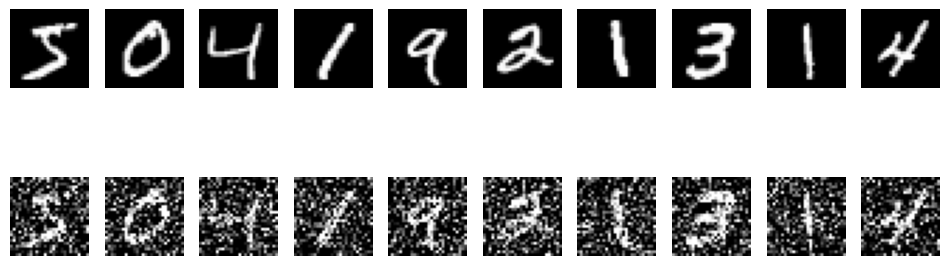

In [31]:
plt.figure(figsize=(12,4))

for i in range(10):

    plt.subplot(2,10,i+1)
    plt.imshow(x_train[i], cmap="gray")
    plt.axis("off")

    plt.subplot(2,10,i+11)
    plt.imshow(x_train_noisy[i], cmap="gray")
    plt.axis("off")

plt.show()

### Observation
The added Gaussian noise significantly degrades the image quality while preserving the overall digit structure. These noisy images serve as inputs to the autoencoder.

#Flatten Images

In [33]:
x_train = x_train.reshape((len(x_train),784))
x_test = x_test.reshape((len(x_test),784))

x_train_noisy = x_train_noisy.reshape((len(x_train_noisy),784))
x_test_noisy = x_test_noisy.reshape((len(x_test_noisy),784))

#AutoEncoder

In [34]:
input_img = Input(shape=(784,))

In [35]:
#Encoder
encoded = Dense(128, activation="relu")(input_img)

encoded = Dense(64, activation="relu")(encoded)

encoded = Dense(32, activation="relu")(encoded)

In [36]:
#Decoder
decoded = Dense(64, activation="relu")(encoded)

decoded = Dense(128, activation="relu")(decoded)

decoded = Dense(784, activation="sigmoid")(decoded)

#Model

In [37]:
#Model Creation
autoencoder = Model(input_img, decoded)

In [38]:
autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,384 (868.69 KB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)

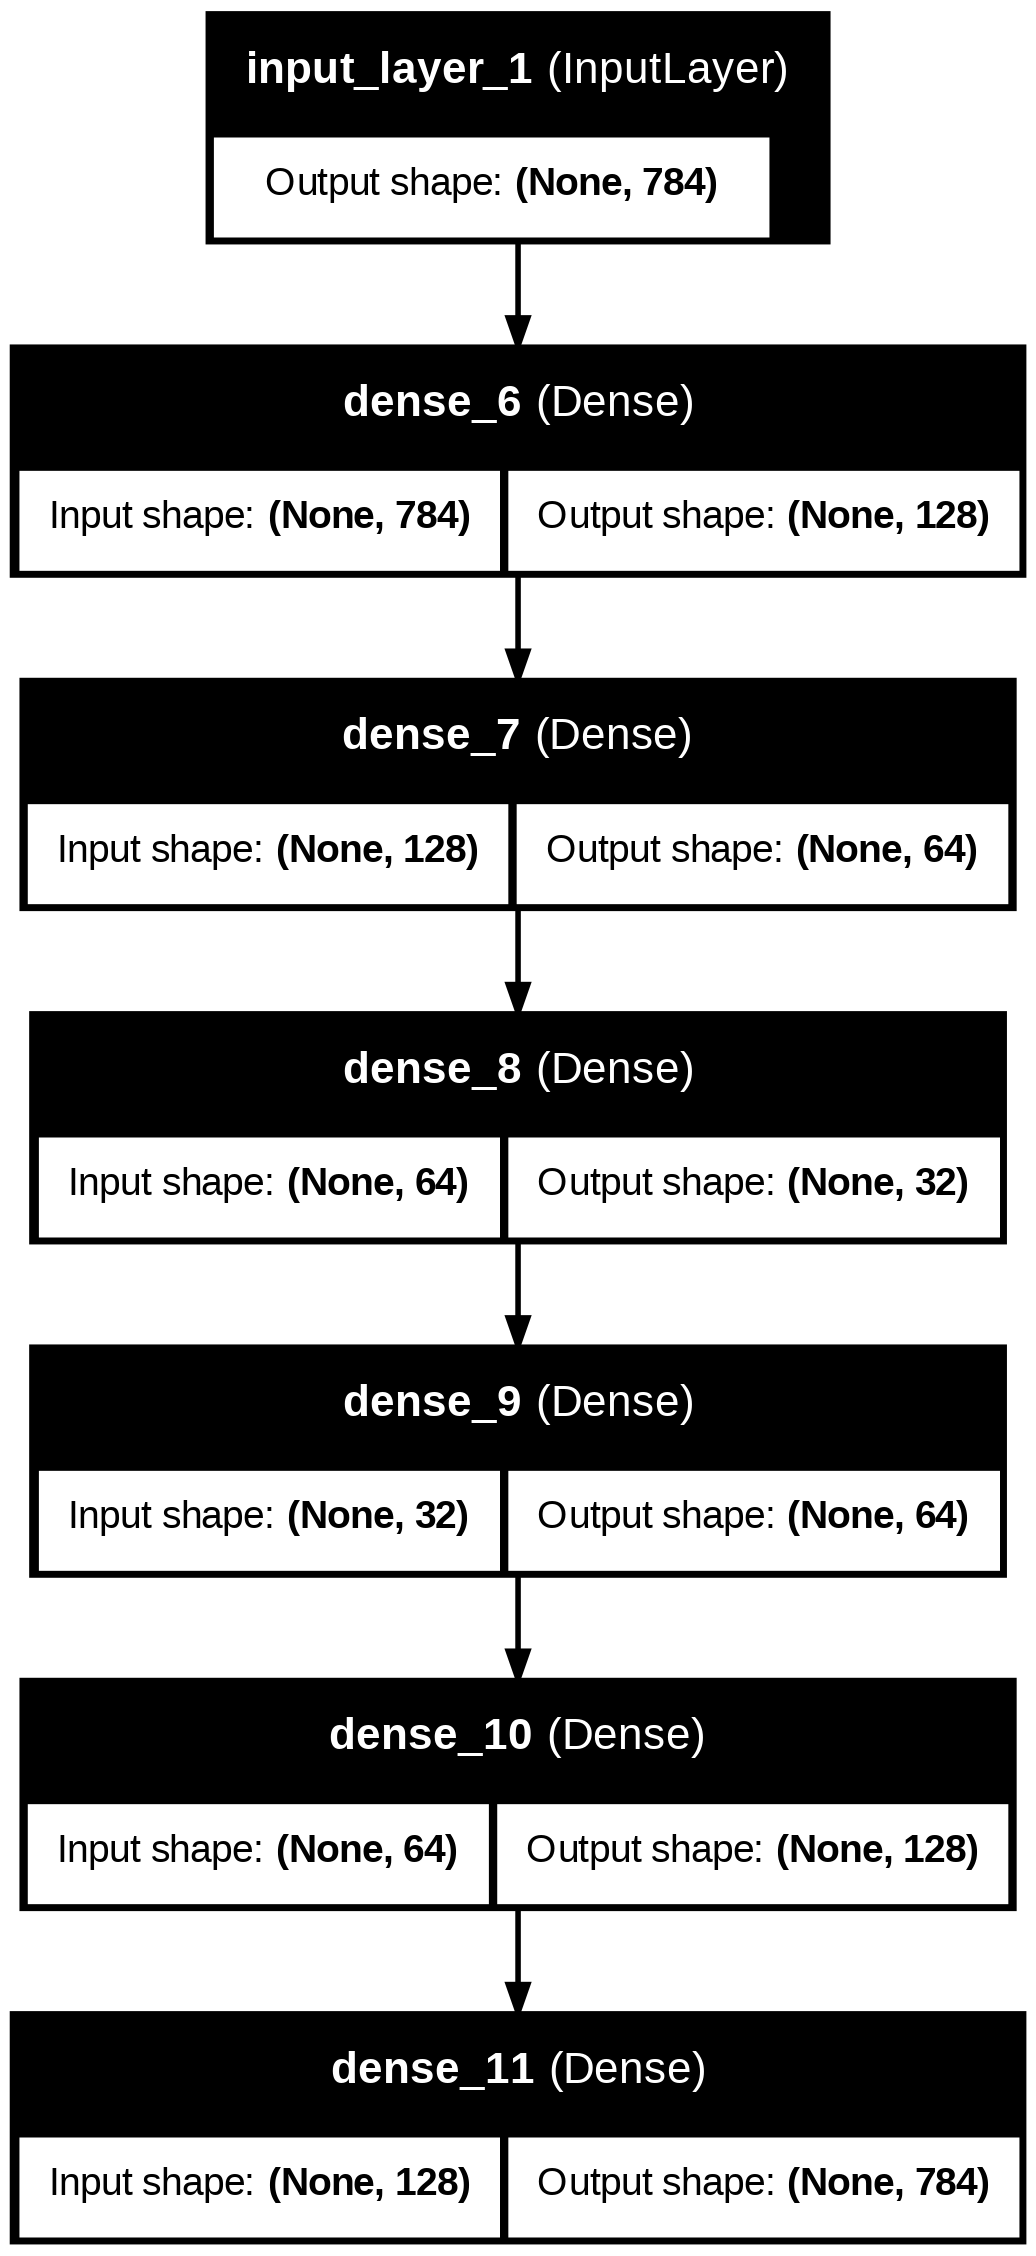

In [39]:
#Summary
autoencoder.summary()
from tensorflow.keras.utils import plot_model

plot_model(
    autoencoder,
    show_shapes=True,
    show_layer_names=True
)

In [41]:
import time

start = time.time()

history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

end = time.time()

print(f"Training Time: {end - start:.2f} seconds")

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.1787 - val_loss: 0.1646
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1609 - val_loss: 0.1551
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1541 - val_loss: 0.1504
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.1492 - val_loss: 0.1462
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.1450 - val_loss: 0.1420
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - loss: 0.1417 - val_loss: 0.1394
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.1389 - val_loss: 0.1375
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1366 - val_loss: 0.1348
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.1347 - val_loss: 0.1334
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.1334 - val_loss: 0.1329
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1320 - val_loss: 0.1312
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 

In [42]:
#Predict
decoded_imgs = autoencoder.predict(x_test_noisy)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [47]:
#Reshape for Display
decoded_imgs = decoded_imgs.reshape(-1,28,28)

x_test_noisy = x_test_noisy.reshape(-1,28,28)

x_test = x_test.reshape(-1,28,28)

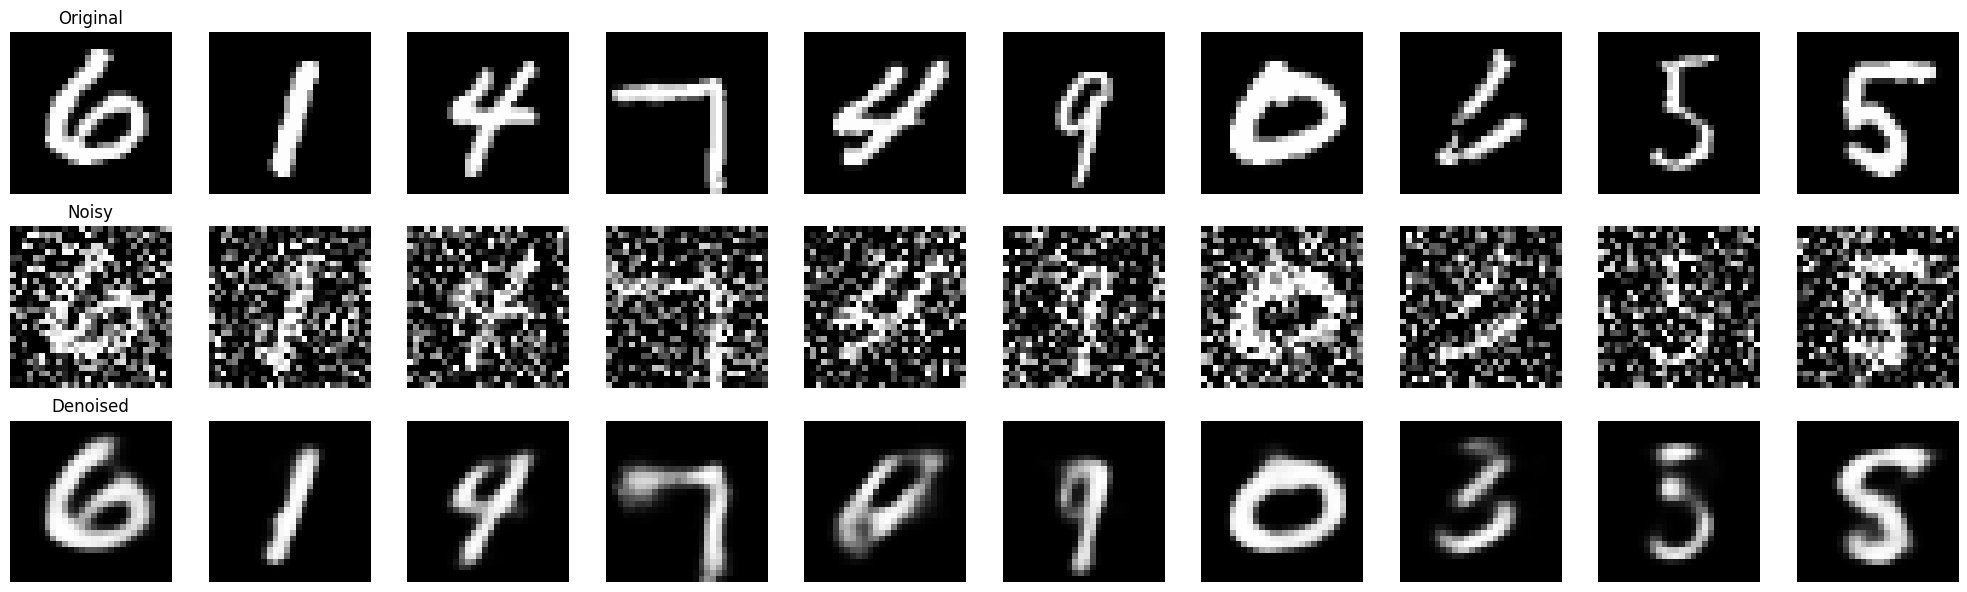

In [48]:
# Select 10 random images
indices = np.random.randint(0, len(x_test), 10)

plt.figure(figsize=(20, 6))

for i, idx in enumerate(indices):

    # Original Image
    ax = plt.subplot(3, 10, i + 1)
    plt.imshow(x_test[idx], cmap='gray')
    plt.axis('off')
    if i == 0:
        ax.set_title("Original")

    # Noisy Image
    ax = plt.subplot(3, 10, i + 11)
    plt.imshow(x_test_noisy[idx], cmap='gray')
    plt.axis('off')
    if i == 0:
        ax.set_title("Noisy")

    # Denoised Image
    ax = plt.subplot(3, 10, i + 21)
    plt.imshow(decoded_imgs[idx], cmap='gray')
    plt.axis('off')
    if i == 0:
        ax.set_title("Denoised")

plt.tight_layout()
plt.show()

Training Curves

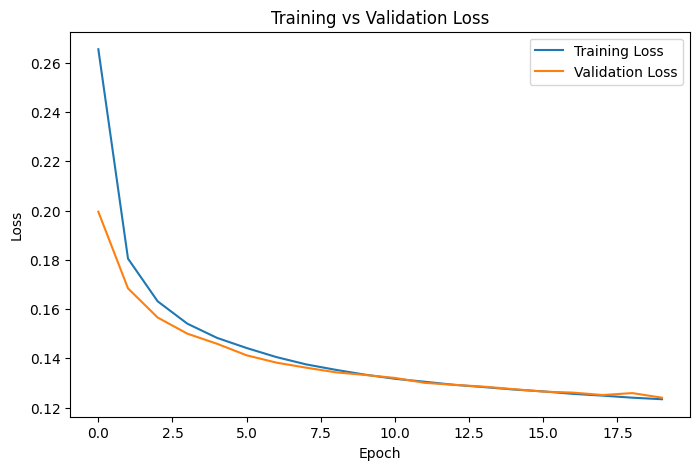

In [20]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [49]:
#MSE
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(
    x_test.reshape(-1),
    decoded_imgs.reshape(-1)
)

print("Mean Squared Error:", mse)

Mean Squared Error: 0.020426055416464806


In [50]:
autoencoder.save("mnist_denoising_autoencoder.keras")

## Conclusion
A Denoising Autoencoder was successfully developed using TensorFlow and Keras. The model effectively removed Gaussian noise from handwritten digit images while preserving their structural features. The decreasing training and validation loss indicate that the model learned meaningful latent representations without significant overfitting. This demonstrates the capability of autoencoders for image restoration tasks.